# README

general introduction of MoE: <https://huggingface.co/blog/moe>

[ST-MoE](https://arxiv.org/abs/2202.08906)

[deepseek v3](../papers/DeepSeek_V3.pdf)

[deepseek v2](../papers/DeepSeek_V2.pdf)



# Moe


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# print if cuda is available
print(torch.cuda.is_available())

True


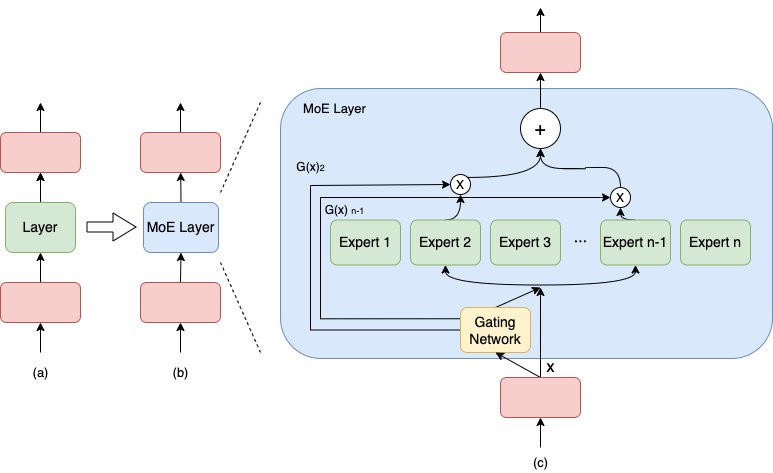

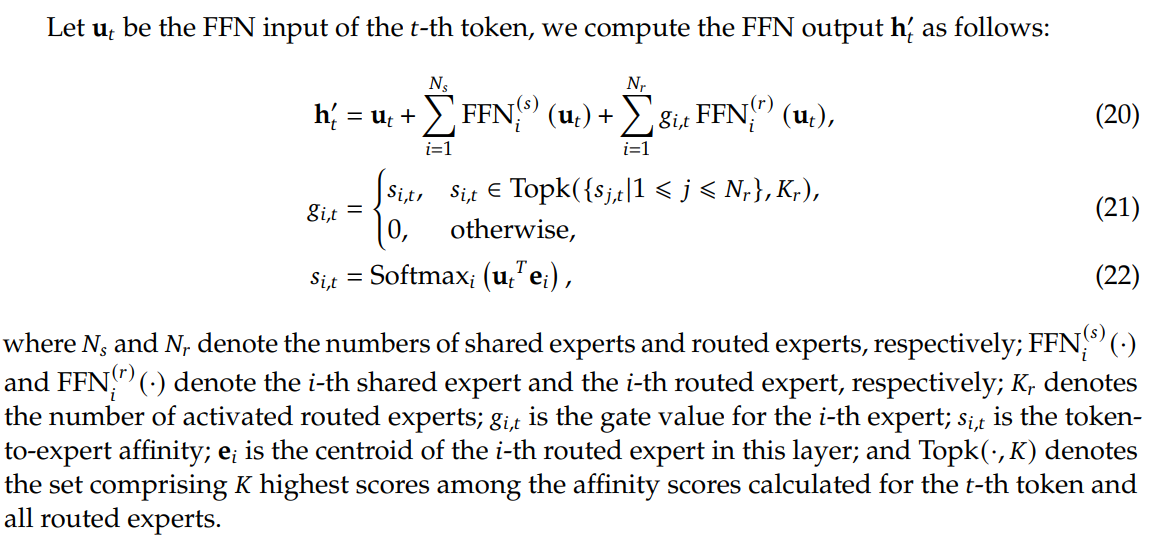

In [38]:
# realise a simple Moe layer
class MoeLayer(nn.Module):
    def __init__(
        self,
        num_routed_experts,
        num_shared_experts,
        expert_size,
        input_size,
        num_activated_experts,
    ):
        super(MoeLayer, self).__init__()
        self.num_routed_experts = num_routed_experts
        self.num_shared_experts = num_shared_experts
        self.expert_size = expert_size
        self.input_size = input_size
        self.num_activated_experts = num_activated_experts
        self.routed_experts = nn.Parameter(
            torch.Tensor(num_routed_experts, expert_size, input_size)
        )
        self.gates = nn.Parameter(torch.Tensor(num_routed_experts, input_size))
        self.shared_experts = nn.Parameter(
            torch.Tensor(num_shared_experts, expert_size, input_size)
        )

        self.init_parameters()

    def init_parameters(self):
        nn.init.xavier_uniform_(self.routed_experts)
        nn.init.xavier_uniform_(self.gates)
        nn.init.xavier_uniform_(self.shared_experts)
    
    def forward(self, x):
        # x: (batch_size, input_size)
        # routed_experts: (num_routed_experts, expert_size, input_size)
        # gates: (num_routed_experts, input_size)
        # shared_experts: (num_shared_experts, expert_size, input_size)
        # output: (batch_size, expert_size)

        # compute the gate_scores
        # gate_scores: (batch_size, num_routed_experts)
        gate_scores = torch.einsum("ni,bi->bn", self.gates, x)
        # topk_values: (batch_size, num_activated_experts)
        # topk_indices: (batch_size, num_activated_experts)
        topk_values, topk_indices = torch.topk(gate_scores, self.num_activated_experts, dim=1)
        
        # selected_experts: (batch_size, num_activated_experts, expert_size, input_size)
        selected_experts = self.routed_experts[topk_indices]
        # x: (batch_size, input_size)
        # expert_outputs: (batch_size, num_activated_experts, expert_size)
        expert_outputs = torch.einsum("bnei,bi->bne", selected_experts, x)
        
        # compute shared_expert_outputs
        # shared_expert_outputs: (batch_size, num_shared_experts, expert_size)
        shared_expert_outputs = torch.einsum("nei,bi->bne", self.shared_experts, x)
        
        # output: (batch_size, expert_size)
        output = torch.cat([expert_outputs, shared_expert_outputs], dim=1)
        output = torch.sum(output, dim=1)
        return output
    
    
    def train(self, mode=True):
        super().train(mode)
        if mode: 
            self.init_parameters()
        return self
        
        

In [40]:
# a simple sample
moe_layer = MoeLayer(
    num_routed_experts=3,
    num_shared_experts=6,
    expert_size=4,
    input_size=5,
    num_activated_experts=2,
)
batch_size = 10
input = torch.randn(batch_size, 5)
moe_layer(input).shape

torch.Size([10, 4])